In [1]:
import torch
import torch.nn as nn
import snntorch as snn
import snntorch.functional.probe as probe
from eleanor.learner import TwoPhasePlasticity
from eleanor.models.torch import Heracles

In [2]:
from snntorch.functional.probe import BaseMonitor


class AttributeMonitor(BaseMonitor):
    def __init__(
        self,
        attribute_name: str,
        pre_forward: bool,
        m: nn.Module,
        function_on_attribute=lambda x: x,
    ):
        super().__init__()
        self.attribute_name = attribute_name
        self.function_on_attribute = function_on_attribute
        name = "learner"

        self.monitored_layers.append(name)
        self.name_records_index[name] = []
        if pre_forward:
            self.hooks.append(m.register_forward_pre_hook(self.create_hook(name)))
        else:
            self.hooks.append(m.register_forward_hook(self.create_hook(name)))

    def create_hook(self, name):
        def hook(m, x, y):
            if self.is_enable():
                self.name_records_index[name].append(self.records.__len__())
                self.records.append(
                    self.function_on_attribute(m.__getattr__(self.attribute_name))
                )

        return hook

In [59]:
SEQ_LEN = 20000
input_times = [1000]
output_times = [
    1000,
    2000,
    4000,
]  # , 7000, 7001, 7002, 7003, 7010, 7011, 7012, 7013, 7020, 7021, 7022, 7023]

input_spikes = torch.zeros(SEQ_LEN * 2)
input_spikes = input_spikes.reshape(-1, 1, 2).float()
input_spikes[input_times, 0, 0] = 1

output_spikes = torch.zeros(SEQ_LEN)
output_spikes[output_times] = 1
output_spikes = output_spikes.reshape(-1, 1, 1).float()

synapse = nn.Linear(2, 1, bias=False)
neuron = nn.Linear(1, 1, bias=False)

torch.nn.init.constant_(synapse.weight, 1.0)
torch.nn.init.constant_(neuron.weight, 1.0)

plasticity = TwoPhasePlasticity(synapse=synapse, sn=neuron)
plasticity.dt = 1e-3
plasticity.theta_pro_circuit = 0
# plasticity.tau_z_c = 3600
# plasticity.I_TH = 10e-12
# plasticity.I_INDC = 0e-12
# plasticity.I_TAU = 10e-12
# plasticity.tau_DPI = 100e-3

i_ca_monitor = AttributeMonitor("i_ca", False, plasticity)
v_h_monitor = AttributeMonitor("v_h", False, plasticity)
p_i_monitor = AttributeMonitor("p_i", False, plasticity)
z_ji_monitor = AttributeMonitor("z_ji", False, plasticity)
weight_monitor = AttributeMonitor("weight", False, synapse)

In [60]:
for t in range(len(input_spikes)):
    synapse(input_spikes[t])
    neuron(output_spikes[t])
    plasticity()

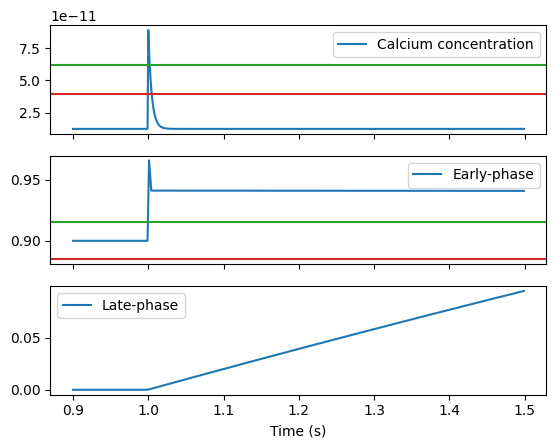

In [61]:
import matplotlib.pyplot as plt

i_ca = torch.stack(i_ca_monitor.records)
v_h = torch.stack(v_h_monitor.records)
p_i = torch.stack(p_i_monitor.records)
z_ji = torch.stack(z_ji_monitor.records)
weight = torch.stack(weight_monitor.records)

T_INI = 900
T_END = 1500
T = torch.arange(T_INI, T_END) * plasticity.dt

epsilon_hi = torch.abs(v_h - plasticity.v_h0)

with torch.no_grad():
    _, ax = plt.subplots(3, 1, sharex=True)
    ax[0].plot(T, i_ca[T_INI:T_END, 0, 0, 0], label="Calcium concentration")
    ax[0].axhline(plasticity.I_THPOT, color="tab:green")
    ax[0].axhline(plasticity.I_THDEP, color="tab:red")
    ax[0].legend()

    ax[1].plot(T, v_h[T_INI:T_END, 0, 0, 0], label="Early-phase")
    ax[1].axhline(plasticity.v_h0 + plasticity.theta_tag_c, color="tab:green")
    ax[1].axhline(plasticity.v_h0 - plasticity.theta_tag_c, color="tab:red")
    ax[1].legend()

    ax[2].plot(T, z_ji[T_INI:T_END, 0, 0, 0], label="Late-phase")
    # ax[2].plot(weight[T_INI:T_END, 0, 0], label="Late-phase weight")
    ax[2].legend()
    ax[2].set_xlabel("Time (s)")
    plt.show()

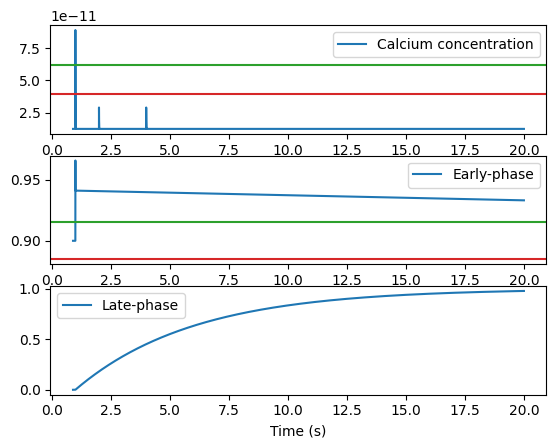

In [62]:
T_END = 20000
T = torch.arange(T_INI, T_END) * plasticity.dt

epsilon_hi = torch.abs(v_h - plasticity.v_h0)

with torch.no_grad():
    _, ax = plt.subplots(3, 1)
    ax[0].plot(T, i_ca[T_INI:T_END, 0, 0, 0], label="Calcium concentration")
    ax[0].axhline(plasticity.I_THPOT, color="tab:green")
    ax[0].axhline(plasticity.I_THDEP, color="tab:red")
    ax[0].legend()

    ax[1].plot(T, v_h[T_INI:T_END, 0, 0, 0], label="Early-phase")
    ax[1].axhline(plasticity.v_h0 + plasticity.theta_tag_c, color="tab:green")
    ax[1].axhline(plasticity.v_h0 - plasticity.theta_tag_c, color="tab:red")
    ax[1].legend()

    ax[2].plot(T, z_ji[T_INI:T_END, 0, 0, 0], label="Late-phase")
    # ax[2].plot(weight[T_INI:T_END, 0, 0], label="Late-phase")
    ax[2].legend()
    ax[2].set_xlabel("Time (s)")
    plt.show()

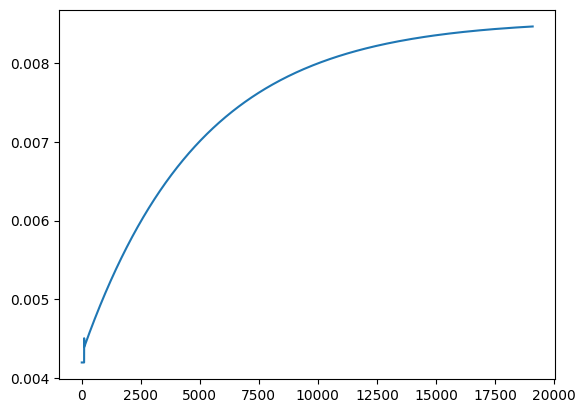

In [63]:
weight = torch.mean(
    plasticity.beta * v_h + plasticity.beta * plasticity.v_h0 * z_ji, dim=1
)
plt.plot(weight[T_INI:T_END, 0, 0])

# Network creation

In [64]:
store_patterns = [[0, 1, 0, 1, 0, 1, 0, 0], [1, 0, 0, 0, 1, 0, 0, 1]]
recall_patterns = [
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [1, 0, 0, 0, 0, 0, 0, 0],
]

## network parameters

In [65]:
partition = [3, 2, 3]  # partition of circuit

N_in = sum(partition)  # number of input neurons
N_pop = N_in  # number of excitatory neurons
N_I = len(partition)  # number of inhibitory neurons
N_aux = 21  # number of auxiliary neurons

## current-based LIF neuron

In [66]:
theta = 1400  # [mV] neural firing threshold
tau_m_exc = 20.0  # [ms] membrane time constant
tau_m_inh = 20.0  # [ms] membrane time constant
tau_arp = 2.0  # [ms] refractory time
V_r_exc = 0.0  # [mV] reset potential
V_r_inh = 0.0  # [mV] reset potential

In [67]:
# The remaining synapses (i.e. non-selective to selective and non-selective to non-selective) have potentiated efficacy with probability 0.1.

J_b = 100.0  # [mV] potentiated synaptic efficacy
J_p = 1.000  # [mV] potentiated synaptic efficacy
J_in = 1.500  # [mV] input synapse strength
J_inh = 1.500  # [mV] inhibitory input from auxiliary neurons
facilitation = 20
p_facilitate_ = 0.5

## short-term synaptic dynamics parameters

In [68]:
U = 0.20  # Baseline utilization factor
tau_F = 15000.0  # [ms] recovery time of utilization factor
tau_D = 20.0  # [ms] recovery time of synaptic resources

ng_base_sc = 100.0  # scaling of random genearator inputs

T_recall = 5000.0
T_store = 2000.0
T_init = 300.0
T_delay_inter_pattern = 800.0
T_delay = 500

In [69]:
50 / 900e-3

55.55555555555556

In [70]:
import numpy as np

# class LognormalSynapse(nn.Module):


class Network(nn.Module):
    def __init__(self):
        super().__init__()
        beta_exc = np.exp(-1 / tau_m_exc)
        beta_inh = np.exp(-1 / tau_m_inh)

        self.exc_input = snn.Leaky(beta_exc, threshold=theta)
        # self.exc_specific = snn.Leaky(beta_exc, threshold=theta)

        self.exc_specific = Heracles(threshold=2.5, paramsScale=1e9, I_dsc=1e-12)
        # self.exc_specific = FeLIF(tau_p=10e-3, tau_m=20e-3, threshold=1.5)

        # self.exc_auxiliary_in = snn.Leaky(beta_exc, threshold=theta)
        # self.exc_auxiliary_out = snn.Leaky(beta_exc, threshold=theta)

        self.exc_input2exc_specific = nn.Linear(N_in, N_pop, bias=False)
        torch.nn.init.eye_(self.exc_input2exc_specific.weight.data)
        self.exc_input2exc_specific.weight.data *= J_in

        self.pop2pop_exc_conn = torch.zeros(N_pop, N_pop)

        # specific2auxin_weight_exc = torch.zeros(N_aux, N_pop)
        # specific2auxin_weight_inh = torch.zeros(N_aux, N_pop)
        # auxout2specific_weight = torch.zeros(N_pop, N_aux)

        # specific_list = np.arange(N_pop)

        s = [[0, 1, 2], [3, 4], [5, 6, 7]]
        all_conn = [
            (i, j)
            for p, q in [(s[u], s[v]) for u in range(len(s)) for v in range(u)]
            for i in p
            for j in q
        ]
        for n, (i, j) in enumerate(all_conn):
            self.pop2pop_exc_conn[i, j] = 1
            self.pop2pop_exc_conn[j, i] = 1
            # specific2auxin_weight_exc[n, i] = J_in
            # specific2auxin_weight_exc[n, j] = J_in

            # for conn in list(np.delete(specific_list,[i,j])):
            #     specific2auxin_weight_inh[n, conn] = -J_inh

            # auxout2specific_weight[i, n] = J_in/20
            # auxout2specific_weight[j, n] = J_in/20
        pop2pop_inh_weight = (
            -J_inh * (1 - self.pop2pop_exc_conn) * (1 - torch.eye(N_pop))
        )

        # self.specific2aux_in = nn.Linear(N_pop, N_aux, bias=False)
        # self.specific2aux_in.weight.data = specific2auxin_weight_exc + specific2auxin_weight_inh

        # self.aux_out2specific = nn.Linear(N_aux, N_pop, bias=False)
        # self.aux_out2specific.weight.data = auxout2specific_weight

        # self.aux_conn = torch.eye(N_aux)
        # self.aux_synapse = nn.Linear(N_aux, N_aux, bias=False)
        # nn.init.ones_(self.aux_synapse.weight)
        # self.aux_synapse.weight.data *= J_p/facilitation

        # logn_mu = 7.7310469224041345
        # logn_sigma = 0.7633766641334044

        self.inh_synapse = nn.Linear(N_pop, N_pop, bias=False)
        self.inh_synapse.weight.data = pop2pop_inh_weight

        self.exc_synapse = nn.Linear(N_pop, N_pop, bias=False)
        # nn.init.ones_(self.exc_synapse.weight)
        self.exc_synapse.weight.data = self.pop2pop_exc_conn * J_p

        # self.sampler = torch.distributions.LogNormal(torch.ones(self.aux_synapse.weight.shape)*logn_mu, torch.ones(self.aux_synapse.weight.shape)*logn_sigma)
        # self.plastic = TwoPhasePlasticity(synapse=self.aux_synapse, sn=self.exc_auxiliary_out)
        self.plastic = TwoPhasePlasticity(
            synapse=self.exc_synapse, sn=self.exc_specific
        )
        self.plastic.dt = 1e-3
        self.plastic.beta = 0.83  # 15 * 55.55555555555556
        self.plastic.theta_pro_circuit = 0
        self.plastic.I_TAILP = 10e-12
        self.plastic.I_TAILD = 1e-12
        self.plastic.delta_capre = 25e-12
        self.plastic.delta_capost = 15e-12
        self.plastic.i_hrn = 2.5e-14
        self.plastic.i_hrp = 2.5e-14
        # self.plastic.v_h0 = J_p/20 #9000e-3
        self.plastic.z_0 = 0.0
        self.plastic.alpha = 1

        # self.plastic.I_TH = 100e-12
        # self.plastic.I_INDC = 25e-12
        # self.plastic.I_TAU = 10e-12
        self.plastic.tau_DPI = 100e-3

        self.reset()

    def reset(self):
        # self.mem_in = self.exc_input.init_leaky()
        # self.mem_sp = self.exc_specific.init_leaky()

        self.exc_input.reset_mem()
        self.exc_specific.reset_mem()
        # self.mem_aux_in = self.exc_auxiliary_in.init_leaky()
        # self.mem_aux_out = self.exc_auxiliary_out.init_leaky()
        self.aux2sp = None
        # self.current_time = 0
        # self.facilitation_time_ = None

    def forward(self, stim):
        if self.aux2sp is None:
            self.aux2sp = torch.zeros(stim.shape[0], N_pop, device=stim.device)

        input_out, _ = self.exc_input(stim)
        in2sp = self.exc_input2exc_specific(input_out)

        sp_out = self.exc_synapse(self.aux2sp) + self.inh_synapse(self.aux2sp)
        # sp_out = self.inh_synapse(self.aux2sp)
        self.aux2sp, _, _ = self.exc_specific(in2sp + sp_out)
        # sp2aux = self.specific2aux_in(sp_out)

        # self.aux2sp = self.inh_synapse(sp_out)

        # aux_in_out, self.mem_aux_in = self.exc_auxiliary_in(sp2aux, self.mem_aux_in)

        # if self.facilitation_time_ is None:
        #     self.facilitation_time_ = torch.zeros_like(self.aux_conn)

        # mask = torch.diag(aux_in_out[0]).bool()

        # is_facilitated = torch.bitwise_and(mask, self.current_time < self.facilitation_time_)
        # condition = torch.bitwise_and(mask, torch.bitwise_or(is_facilitated, torch.rand(self.aux_synapse.weight.shape) < p_facilitate_)).float()
        # new_facilitation_time_ = self.current_time + self.sampler.sample()
        # self.facilitation_time_ = condition * new_facilitation_time_ + (1-condition) * self.facilitation_time_

        # weight = self.aux_synapse.weight.data
        # weight = is_facilitated.float() * 20 * weight + (1-is_facilitated.float()) * weight#J_p / 20
        # torch.clamp_max_(weight, J_p/1.203)
        # self.aux_synapse.weight.data = weight * self.aux_conn

        # aux2aux = self.aux_synapse(aux_in_out)

        # aux_out, self.mem_aux_out = self.exc_auxiliary_out(aux2aux, self.mem_aux_out)
        # self.aux2sp = self.aux_out2specific(aux_out)

        self.plastic()
        self.exc_synapse.weight.data *= self.pop2pop_exc_conn
        # torch.clamp_max_(self.exc_synapse.weight.data, J_inh)
        # self.aux_synapse.weight.data *= self.aux_conn

        # self.current_time += 1

        return input_out, self.aux2sp  # , aux_in_out, aux_out

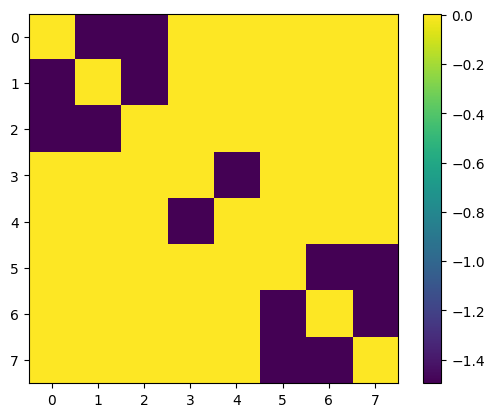

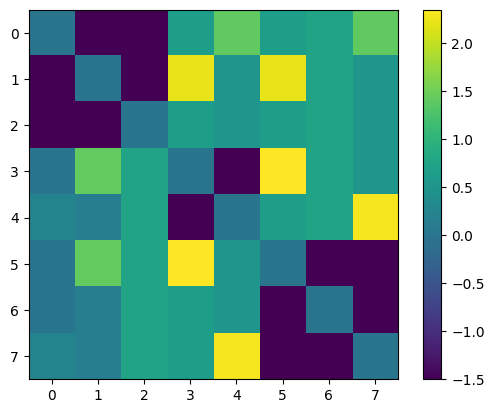

In [71]:
net = Network()
with torch.no_grad():
    plt.figure()
    plt.imshow(net.exc_synapse.weight + net.inh_synapse.weight)
    plt.colorbar()
    plt.show()

mem_prob = probe.AttributeMonitor("mem", False, net, instance=Heracles)
pol_prob = probe.AttributeMonitor("pol", False, net, instance=Heracles)
i_ca_monitor = probe.AttributeMonitor("i_ca", False, net, instance=TwoPhasePlasticity)
v_h_monitor = probe.AttributeMonitor("v_h", False, net, instance=TwoPhasePlasticity)
p_i_monitor = probe.AttributeMonitor("p_i", False, net, instance=TwoPhasePlasticity)
z_ji_monitor = probe.AttributeMonitor("z_ji", False, net, instance=TwoPhasePlasticity)
input_probe = probe.InputMonitor(net, instance=Heracles)

STORE_IN = 2
RECALL_IN = 2

T_total = 0
out_spikes = []

T_total += T_init
for t in range(int(T_init)):
    stim = torch.zeros(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_store
for t in range(int(T_store)):
    stim = STORE_IN * ng_base_sc * torch.tensor(store_patterns[0]).reshape(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_delay
for t in range(int(T_delay)):
    stim = torch.zeros(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_recall
for t in range(int(T_recall)):
    stim = RECALL_IN * ng_base_sc * torch.tensor(recall_patterns[0]).reshape(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

# T_total+=T_delay
# for t in range(int(T_delay)):
#     stim = torch.zeros(1, N_in)
#     outputs = net(stim)

#     out_spikes.append(torch.concat([*outputs], dim=1))


T_total += T_delay_inter_pattern
for t in range(int(T_delay_inter_pattern)):
    stim = torch.zeros(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_store
for t in range(int(T_store)):
    stim = STORE_IN * ng_base_sc * torch.tensor(store_patterns[1]).reshape(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_delay
for t in range(int(T_delay)):
    stim = torch.zeros(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

T_total += T_recall
for t in range(int(T_recall)):
    stim = RECALL_IN * ng_base_sc * torch.tensor(recall_patterns[2]).reshape(1, N_in)
    outputs = net(stim)

    out_spikes.append(torch.concat([*outputs], dim=1))

# T_total+=T_delay
# for t in range(int(T_delay)):
#     stim = torch.zeros(1, N_in)
#     outputs = net(stim)

#     out_spikes.append(torch.concat([*outputs], dim=1))

# T_total+=T_recall
# for t in range(int(T_recall)):
#     stim = RECALL_IN * ng_base_sc * torch.tensor(recall_patterns[2]).reshape(1, N_in)
#     outputs = net(stim)

#     out_spikes.append(torch.concat([*outputs], dim=1))

# T_total+=T_delay
# for t in range(int(T_delay)):
#     stim = torch.zeros(1, N_in)
#     outputs = net(stim)

#     out_spikes.append(torch.concat([*outputs], dim=1))

out_spikes = torch.stack(out_spikes)

with torch.no_grad():
    plt.figure()
    plt.imshow(net.exc_synapse.weight + net.inh_synapse.weight)
    plt.colorbar()
    plt.show()

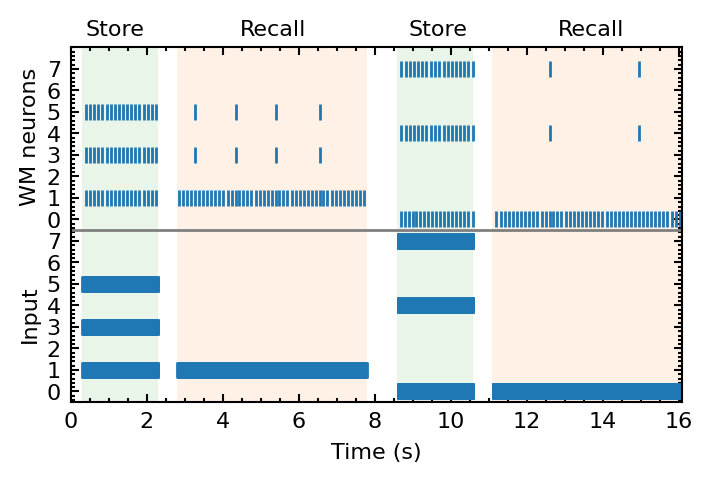

In [72]:
import matplotlib as mpl

with mpl.style.context("boilerplot.ieeetran"):
    _, ax = plt.subplots(figsize=[3.45, 2.3], dpi=200)
    t, idx = torch.where(out_spikes[:, 0])
    ax.plot(t * 1e-3, idx, "|")
    ax.axvspan(
        T_init * 1e-3, (T_init + T_store) * 1e-3, facecolor="tab:green", alpha=0.1
    )
    ax.axvspan(
        (T_init + T_store + T_delay) * 1e-3,
        (T_init + T_store + T_delay + T_recall) * 1e-3,
        facecolor="tab:orange",
        alpha=0.1,
    )
    ax.axvspan(
        (T_init + T_store + T_delay + T_recall + T_delay_inter_pattern) * 1e-3,
        (T_init + T_store + T_delay + T_recall + T_delay_inter_pattern + T_store)
        * 1e-3,
        facecolor="tab:green",
        alpha=0.1,
    )
    ax.axvspan(
        (
            T_init
            + T_store
            + T_delay
            + T_recall
            + T_delay_inter_pattern
            + T_store
            + T_delay
        )
        * 1e-3,
        (
            T_init
            + T_store
            + T_delay
            + T_recall
            + T_delay_inter_pattern
            + T_store
            + T_delay
            + T_recall
        )
        * 1e-3,
        facecolor="tab:orange",
        alpha=0.1,
    )
    ax.axhline(N_in - 0.5, linewidth=1, color="tab:gray")

    ax.text(
        (T_init + T_store) * 1e-3 / 2 / 16,
        1.05,
        "Store",
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
        transform=ax.transAxes,
    )

    prev = T_init + T_store + T_delay
    ax.text(
        (prev + T_init + T_store + T_delay + T_recall) * 1e-3 / 2 / 16,
        1.05,
        "Recall",
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
        transform=ax.transAxes,
    )

    prev = T_init + T_store + T_delay + T_recall + T_delay_inter_pattern
    ax.text(
        (prev + T_init + T_store + T_delay + T_recall + T_delay_inter_pattern + T_store)
        * 1e-3
        / 2
        / 16,
        1.05,
        "Store",
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
        transform=ax.transAxes,
    )

    prev = (
        T_init
        + T_store
        + T_delay
        + T_recall
        + T_delay_inter_pattern
        + T_store
        + T_delay
    )
    ax.text(
        (
            prev
            + T_init
            + T_store
            + T_delay
            + T_recall
            + T_delay_inter_pattern
            + T_store
            + T_delay
            + T_recall
        )
        * 1e-3
        / 2
        / 16,
        1.05,
        "Recall",
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
        transform=ax.transAxes,
    )

    ax.text(
        -0.05,
        0.25,
        "Input",
        horizontalalignment="right",
        verticalalignment="center",
        rotation="vertical",
        transform=ax.transAxes,
    )
    ax.text(
        -0.05,
        0.75,
        "WM neurons",
        horizontalalignment="right",
        verticalalignment="center",
        rotation="vertical",
        transform=ax.transAxes,
    )
    plt.yticks(np.arange(N_in * 2), np.arange(N_in * 2) % N_in)
    plt.xlim(0, T_total * 1e-3)
    plt.ylim(-0.5, N_in + N_pop)
    plt.xlabel("Time (s)")
    plt.show()

/tmp/ipykernel_1119/298172527.py:36: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


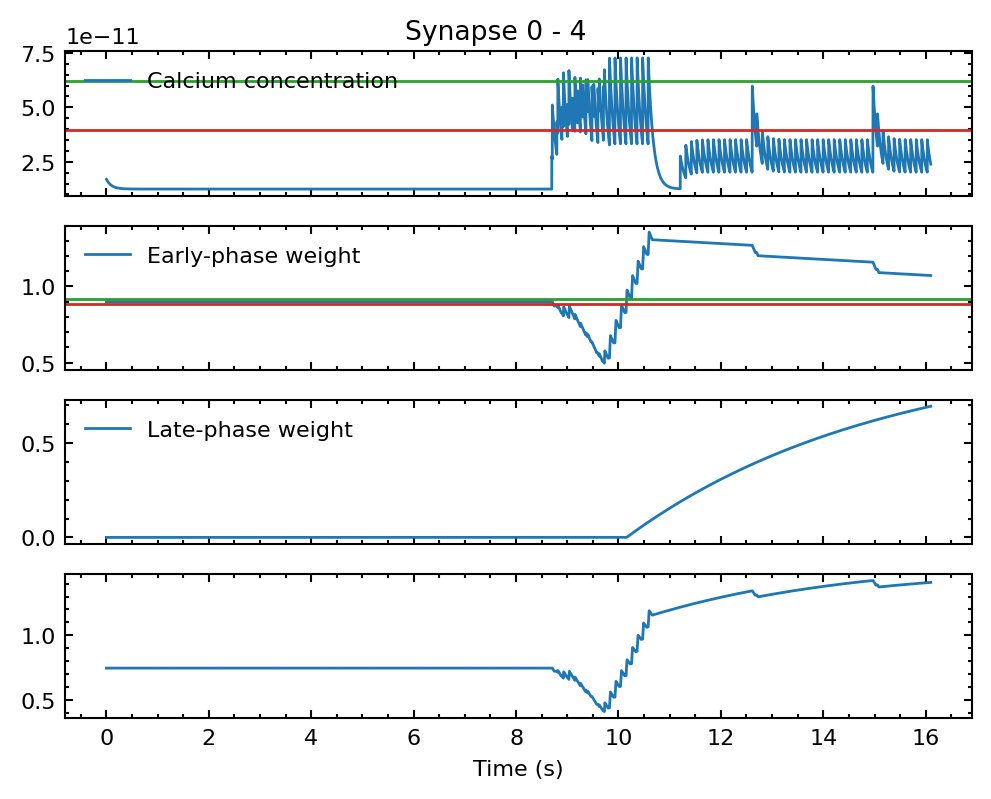

In [73]:
i_ca = torch.stack(i_ca_monitor["plastic"])
v_h = torch.stack(v_h_monitor["plastic"])
p_i = torch.stack(p_i_monitor["plastic"])
z_ji = torch.stack(z_ji_monitor["plastic"])

epsilon_hi = torch.abs(v_h - net.plastic.v_h0)

T_INI = 0
T_END = int(T_total)

INDX = 0
INDY = 4
T = np.arange(T_END) * 1e-3
with mpl.style.context("boilerplot.ieeetran"):
    with torch.no_grad():
        _, ax = plt.subplots(4, 1, figsize=[5, 4], dpi=200, sharex=True)
        ax[0].plot(T, i_ca[T_INI:T_END, 0, INDX, INDY], label="Calcium concentration")
        ax[0].axhline(net.plastic.I_THPOT, color="tab:green")
        ax[0].axhline(net.plastic.I_THDEP, color="tab:red")
        ax[0].legend()

        ax[1].plot(T, v_h[T_INI:T_END, 0, INDX, INDY], label="Early-phase weight")
        ax[1].axhline(net.plastic.v_h0 + net.plastic.theta_tag_c, color="tab:green")
        ax[1].axhline(net.plastic.v_h0 - net.plastic.theta_tag_c, color="tab:red")
        ax[1].legend()

        # ax[2].plot(p_i[T_INI:T_END,0,0,0], label='Early-phase weight')
        ax[2].plot(T, z_ji[T_INI:T_END, 0, INDX, INDY], label="Late-phase weight")
        ax[2].legend()

        weight = torch.mean(
            net.plastic.beta * v_h + net.plastic.beta * net.plastic.v_h0 * z_ji, dim=1
        )
        ax[3].plot(T, weight[T_INI:T_END, INDX, INDY], label="Late-phase weight")
        plt.xlabel("Time (s)")
        plt.tight_layout()
        plt.suptitle(f"Synapse {INDX} - {INDY}")
        plt.show()

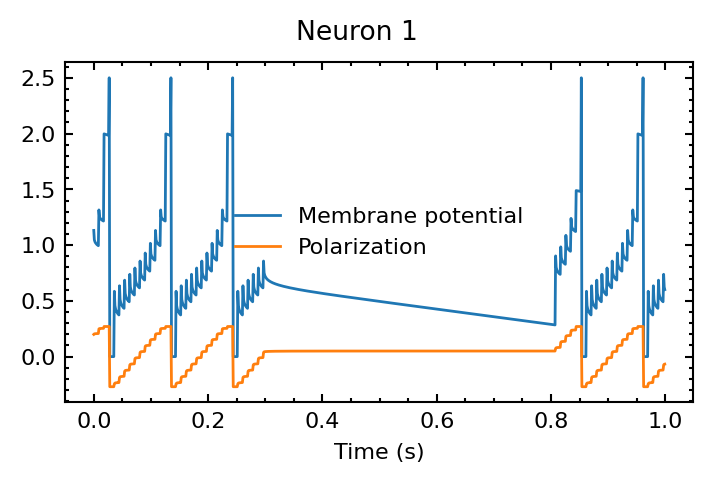

In [74]:
with mpl.style.context("boilerplot.ieeetran"):
    with torch.no_grad():

        mem_in = torch.stack(mem_prob["exc_specific"])
        pol_in = torch.stack(pol_prob["exc_specific"])
        cur_in = torch.stack(input_probe["exc_specific"])
        plt.figure(figsize=[3.45, 2.3], dpi=200)
        plt.plot(
            np.arange(1000) * 1e-3, mem_in[2000:3000, 0, 1], label="Membrane potential"
        )
        plt.plot(np.arange(1000) * 1e-3, pol_in[2000:3000, 0, 1], label="Polarization")
        plt.xlabel("Time (s)")
        plt.legend()
        plt.suptitle("Neuron 1")
        plt.show()